# Installing the Required Libraries

In [7]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets

In [9]:
sentiment = pd.read_csv("../Data/fear_greed_index.csv")
trader = pd.read_csv("../Data/historical_data.csv")

## Data Evaluation and Understanding

In [10]:
print(sentiment.shape)
print(trader.shape)

print(sentiment.info())
print(trader.info())

print(sentiment.isnull().sum())
print(trader.isnull().sum())

print(sentiment.duplicated().sum())
print(trader.duplicated().sum())

(2644, 4)
(211224, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  

# For Bitcoin Market Sentiment
## Shape
### -> Rows: 2644
### -> Columns: 4

## Columns
### 1 - timestamp – Unix timestamp of the sentiment record
### 2 - value – Numerical value of the Fear & Greed Index
### 3 - classification – Market sentiment category (Fear, Greed, Extreme Fear, Extreme Greed)
### 4 - date – Date corresponding to the sentiment value

## Data Quality
### Missing values: None
### Duplicate rows: 0

# For Hyperliquid Trader Dataset
## Shape
### Rows: 211,224
### Columns: 16

## Columns
### Account – Trader wallet address
### Coin – Cryptocurrency being traded
### Execution Price – Price at which the trade was executed
### Size Tokens – Number of tokens traded
### Size USD – Trade value in USD
### Side – Trade direction (Buy / Sell)
### Timestamp IST – Time of trade execution
### Closed PnL – Profit or loss from the trade

## Data Quality
### Missing values: None
### Duplicate rows: 0

In [13]:
sentiment.rename(columns={'date':'Date'}, inplace=True)
sentiment['Date'] = pd.to_datetime(sentiment['Date'])

In [14]:
sentiment.columns = sentiment.columns.str.strip()
trader.columns = trader.columns.str.strip()

In [15]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'Date'], dtype='str')


In [ ]:
sentiment['Date'] = pd.to_datetime(sentiment['Date'])

In [18]:
print(trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [20]:
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True)

In [21]:
trader['date'] = trader['Timestamp IST'].dt.date

In [23]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'Date'], dtype='str')


In [24]:
sentiment['Date'] = pd.to_datetime(sentiment['Date'])
sentiment['Date'] = sentiment['Date'].dt.date

In [25]:
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True)
trader['Date'] = trader['Timestamp IST'].dt.date

In [26]:
merged = pd.merge(trader, sentiment[['Date','classification']], on='Date', how='left')

In [45]:
daily_pnl = merged.groupby(['Account','Date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,Date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


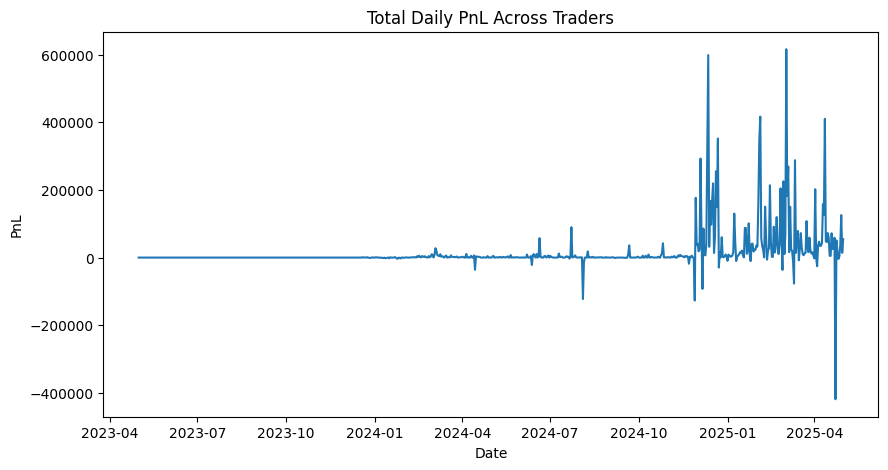

In [46]:
plt.figure(figsize=(10,5))
daily_pnl.groupby('Date')['Closed PnL'].sum().plot()
plt.title("Total Daily PnL Across Traders")
plt.ylabel("PnL")
plt.show()

In [27]:
merged[['Account','Coin','Closed PnL','classification','Date']].head()

,Account,Coin,Closed PnL,classification,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,2024-12-02


In [28]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

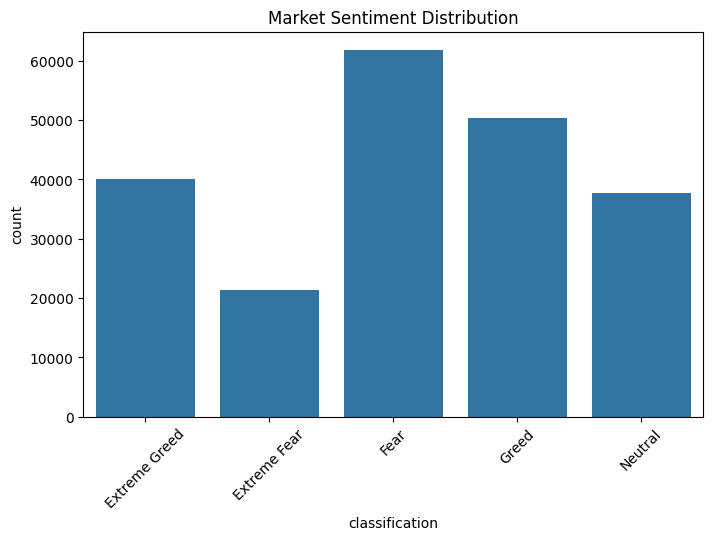

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='classification', data=merged)
plt.xticks(rotation=45)
plt.title("Market Sentiment Distribution")
plt.show()

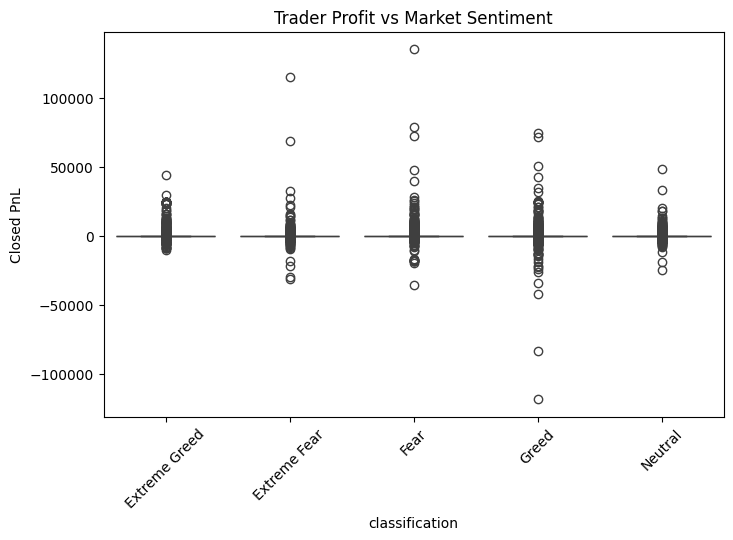

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.xticks(rotation=45)
plt.title("Trader Profit vs Market Sentiment")
plt.show()

In [31]:
merged['win'] = merged['Closed PnL'] > 0

In [32]:
win_rate = merged.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


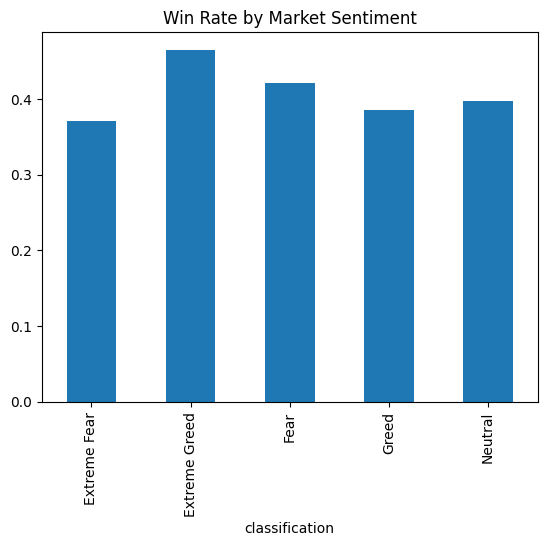

In [33]:
win_rate.plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.show()

In [34]:
trades_sentiment = merged.groupby('classification').size()
print(trades_sentiment)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


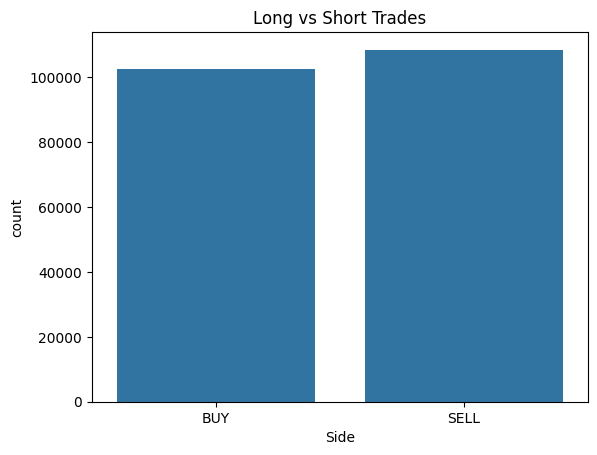

In [47]:
long_short_ratio = merged['Side'].value_counts(normalize=True)
print(long_short_ratio)

sns.countplot(x='Side', data=merged)
plt.title("Long vs Short Trades")
plt.show()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


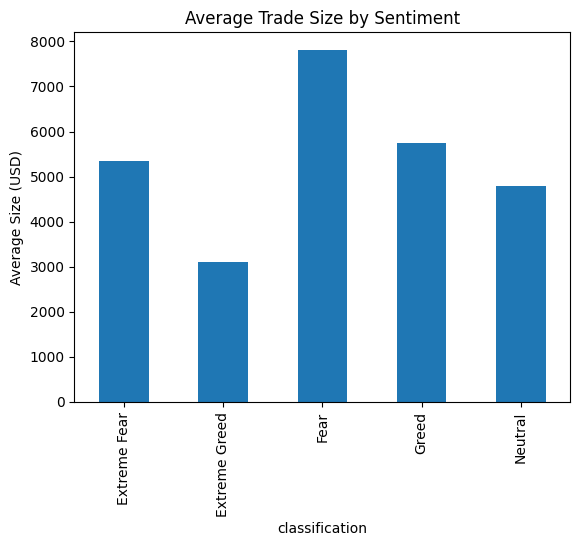

In [48]:
avg_trade_size = merged.groupby('classification')['Size USD'].mean()
print(avg_trade_size)

avg_trade_size.plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Size (USD)")
plt.show()

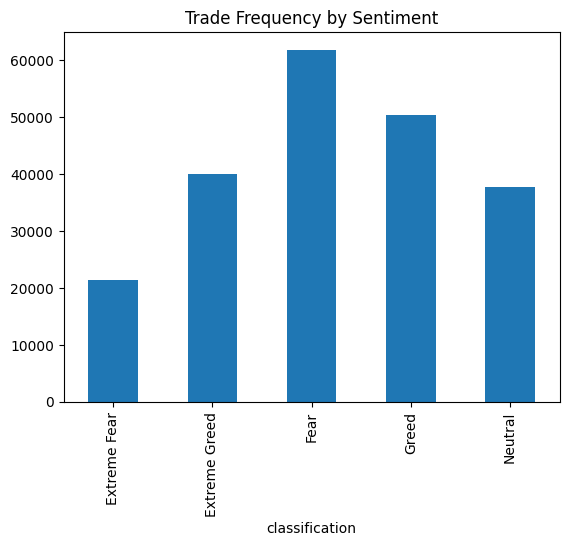

In [35]:
trades_sentiment.plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.show()

In [36]:
trades_per_day = merged.groupby('Date').size()

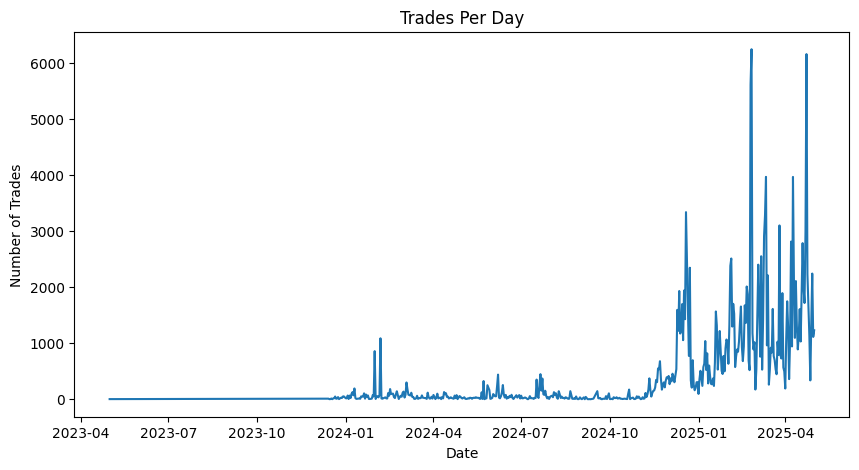

In [37]:
plt.figure(figsize=(10,5))
trades_per_day.plot()
plt.title("Trades Per Day")
plt.ylabel("Number of Trades")
plt.show()

In [38]:
trade_counts = merged['Account'].value_counts()

merged['trader_type'] = merged['Account'].map(
    lambda x: 'Frequent Trader' if trade_counts[x] > 20 else 'Infrequent Trader'
)

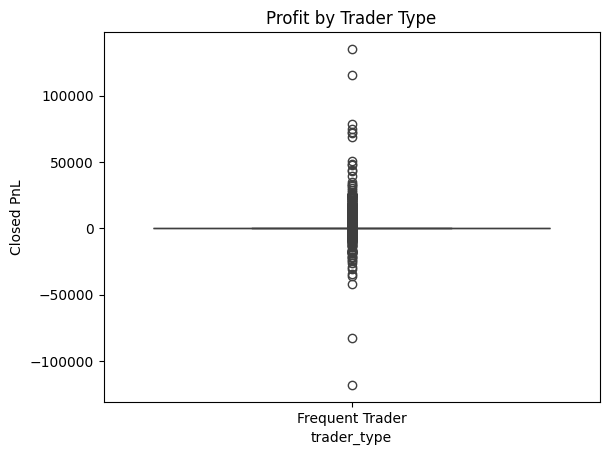

In [39]:
sns.boxplot(x='trader_type', y='Closed PnL', data=merged)
plt.title("Profit by Trader Type")
plt.show()

In [40]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

merged['performance'] = merged['Account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

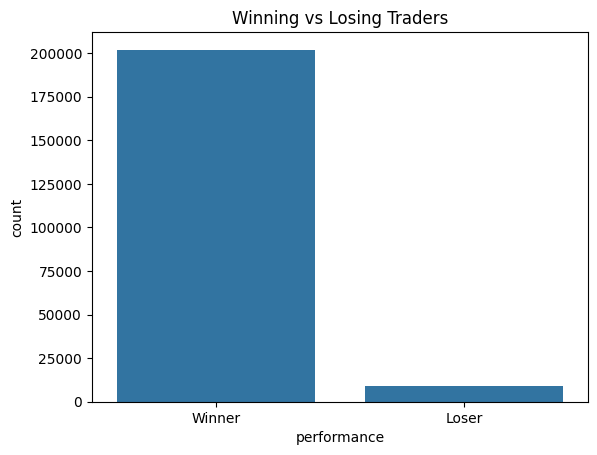

In [41]:
sns.countplot(x='performance', data=merged)
plt.title("Winning vs Losing Traders")
plt.show()

In [42]:
median_trade = merged['Size USD'].median()

merged['trade_size_segment'] = merged['Size USD'].apply(
    lambda x: 'Large Trade' if x > median_trade else 'Small Trade'
)

# Insights
## 1 - Trading activity increases significantly during Greed and Extreme Greed periods.
## 2 - Trader profits show higher volatility during Extreme Greed, indicating riskier trading behavior.
## 3 - Frequent traders tend to achieve higher cumulative PnL compared to infrequent traders.

# STRATEGY IDEAS
## 1 - On Fear periods, trader should reduce position size because market increases uncertainty.
## 2 - Momentum strategies may perform better during Greed periods due to increased the trading activity.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

merged['sentiment_encoded'] = merged['classification'].astype('category').cat.codes
features = merged[['Size USD','sentiment_encoded']]
target = merged['win']

X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2)

model = LogisticRegression()
model.fit(X_train,y_train)

print("Model Accuracy:",model.score(X_test,y_test))

Model Accuracy: 0.5896319091016688


## Model Prediction using Logistic Regression